<div style="background:#005A67;padding:28px;border-radius:18px;color:white">
  <p style="margin:0;color:#F6BD38;font-weight:700;letter-spacing:1px">PROJETO INTEGRADOR · FUNDAMENTOS DE IA E PROGRAMAÇÃO</p>
  <h1 style="margin:8px 0 4px">Rota em Dia</h1>
  <h3 style="margin:0;font-weight:400">Por que os ônibus fretados estão chegando atrasados?</h3>
</div>

**Equipe:** Juliana Ballin Lima · Fernanda de Oliveira da Costa · Pedro Henrique Oliveira Dias  
**Período analisado:** fevereiro a maio de 2026 · **Escopo:** 8 rotas e 3 turnos

[Consultar o relatório técnico descritivo](https://github.com/JulianaBallin/TransitTrace/blob/main/docs/relatorio/relatorio_tecnico_rota_em_dia.pdf)

> **Pergunta central:** Por que os atrasos do transporte fretado aumentaram, onde se concentram e quais evidências sustentam a explicação mais plausível?

## Contexto do Desafio

Os colaboradores de uma fábrica de eletroeletrônicos do Distrito Industrial de Manaus chegam para os três turnos em ônibus fretados, em oito rotas que saem de diferentes zonas da cidade. Cada ônibus deve chegar à fábrica 15 minutos antes do início do turno. O RH recebeu reclamações de colaboradores chegando atrasados à linha e pediu uma análise das viagens de fevereiro a maio de 2026, período de chuvas. O desafio é investigar os dados ao longo das quatro unidades do curso e construir uma explicação tecnicamente defensável.

**Dataset principal:** `projeto_integrador_transporte_fretado.csv`

**Indicador principal:** pontualidade (%) = viagens que chegaram até 5 minutos depois do horário previsto ÷ total de viagens × 100.

**Indicadores complementares:** atraso em minutos, representado pela mediana, e viagens que chegaram depois do início do turno, com atraso maior que 15 minutos.

## Como executar no Google Colab

1. Faça upload deste notebook e do arquivo `projeto_integrador_transporte_fretado.csv` na mesma sessão.
2. Clique em **Ambiente de execução > Executar tudo**.
3. Se o CSV não for encontrado, a primeira célula solicitará o upload.

O notebook preserva a base bruta em `raw` e cria a base tratada em `data`. Nenhuma correção é feita silenciosamente.

In [1]:
# Importa as bibliotecas usadas na leitura, análise e visualização.
from pathlib import Path
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

# Mantém a mesma paleta visual em todos os gráficos.
CREAM = "#FFF8E8"
TEAL = "#005A67"
MINT = "#65C3A5"
CORAL = "#F06449"
YELLOW = "#F6BD38"
INK = "#17343A"
GRAY = "#A7B0B3"

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": CREAM,
    "axes.facecolor": CREAM,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "grid.color": "#D8E0E0",
})

def parse_dates(values):
    '''Parse ISO and day-first dates without ambiguity.'''
    # Separa os dois formatos encontrados antes da conversão.
    text = values.astype("string").str.strip()
    is_iso = text.str.fullmatch(r"\d{4}-\d{2}-\d{2}").fillna(False)
    parsed = pd.to_datetime(
        text.where(is_iso), format="%Y-%m-%d", errors="coerce"
    )
    return parsed.fillna(
        pd.to_datetime(
            text.where(~is_iso), format="%d/%m/%Y", errors="coerce"
        )
    )

In [2]:
# Procura o CSV na estrutura do repositório e no diretório do Colab.
candidates = [
    Path("dataset/projeto_integrador_transporte_fretado.csv"),
    Path("projeto_integrador_transporte_fretado.csv"),
    Path("/content/projeto_integrador_transporte_fretado.csv"),
]
data_path = next((path for path in candidates if path.exists()), None)

if data_path is None:
    # Solicita o arquivo somente quando ele não está disponível.
    from google.colab import files
    uploaded = files.upload()
    csv_name = next(name for name in uploaded if name.endswith(".csv"))
    data_path = Path(csv_name)

raw = pd.read_csv(data_path)
print(f"Arquivo: {data_path}")
print(f"Dimensão: {raw.shape[0]} linhas × {raw.shape[1]} colunas")

Arquivo: dataset/projeto_integrador_transporte_fretado.csv
Dimensão: 2463 linhas × 11 colunas


## Roteiro da investigação

| Etapa | Pergunta | Produto |
|---|---|---|
| 1 · Primeiro diagnóstico | O que parece estar acontecendo? | Indicadores iniciais e hipóteses concorrentes |
| 2 · Estatística | Onde, quando e com que intensidade? | Comparações, variabilidade e hipóteses atualizadas |
| 3 · Limpeza | Podemos confiar nos dados? | Pipeline, validação e comparação antes × depois |
| 4 · EDA | Qual explicação é mais plausível? | Cinco visualizações, conclusão e recomendações |

**Regra de leitura:** evidência observada, interpretação, hipótese e limitação aparecem separadas ao longo do notebook.

# Etapa 1 · Primeiro diagnóstico

Nesta etapa a base é observada como foi recebida. Não corrigimos rótulos, duplicatas ou valores extremos.

**Contribuição para a pergunta central:** localizar os primeiros indícios do problema e formular explicações concorrentes.

In [3]:
preview = raw.head(6)
display(preview)

# Converte apenas uma cópia das datas para descrever o período bruto.
parsed_dates = parse_dates(raw["data"])
diagnosis = pd.DataFrame({
    "informação": ["Linhas", "Colunas", "Início", "Fim", "Dias de operação"],
    "valor": [
        len(raw),
        raw.shape[1],
        parsed_dates.min().strftime("%d/%m/%Y"),
        parsed_dates.max().strftime("%d/%m/%Y"),
        parsed_dates.nunique(),
    ],
})
display(diagnosis)
display(raw.dtypes.rename("tipo").to_frame())

,data,turno,rota,zona_origem,empresa,horario_previsto,horario_chegada,atraso_min,passageiros,chuva_mm,ocorrencia
0,2026-02-02,Manhã,R01,Norte,Viação Alfa,05:45,05:44,-1,33,0.0,Nenhuma
1,2026-02-02,manha,R02,Norte,Viação Alfa,05:45,05:43,-2,34,0.0,Nenhuma
2,2026-02-02,Manhã,R03,Leste,Viação Beta,05:45,05:36,-9,39,0.0,Nenhuma
3,2026-02-02,Manhã,R04,Sul,Viação Alfa,05:45,05:39,-6,120,0.0,Nenhuma
4,2026-02-02,Manhã,R05,Leste,Viação Beta,05:45,05:42,-3,35,0.0,Nenhuma
5,2026-02-02,Manhã,R06,Oeste,Viação Alfa,05:45,05:42,7,41,0.0,Nenhuma


,informação,valor
0,Linhas,2463
1,Colunas,11
2,Início,02/02/2026
3,Fim,30/05/2026
4,Dias de operação,102


,tipo
data,object
turno,object
rota,object
zona_origem,object
empresa,object
horario_previsto,object
horario_chegada,object
atraso_min,int64
passageiros,int64
chuva_mm,float64


### Indicador principal

Uma viagem é **pontual** quando chega no máximo 5 minutos após o horário previsto.

**Pontualidade (%) = viagens com atraso ≤ 5 min ÷ total de viagens × 100.**

O atraso acima de 15 minutos é analisado separadamente, pois o ônibus deveria chegar 15 minutos antes do início do turno.

In [4]:
# Calcula os indicadores iniciais sem alterar a base bruta.
raw_analysis = raw.assign(pontual=raw["atraso_min"].le(5))

overall_raw = pd.DataFrame({
    "indicador": ["Pontualidade", "Mediana do atraso", "Chegadas após o início do turno"],
    "resultado": [
        f"{raw_analysis['pontual'].mean() * 100:.1f}%",
        f"{raw_analysis['atraso_min'].median():.0f} min",
        f"{raw_analysis['atraso_min'].gt(15).sum()} viagens",
    ],
})
display(overall_raw)

def punctuality_table(frame, group):
    '''Summarize trip count and punctuality for one grouping.'''
    # Agrupa viagens e ordena do pior para o melhor resultado.
    return (
        frame.groupby(group, dropna=False)["pontual"]
        .agg(viagens="size", pontualidade="mean")
        .assign(pontualidade=lambda table: table["pontualidade"] * 100)
        .sort_values("pontualidade")
        .round(1)
    )

display(punctuality_table(raw_analysis, "rota").head(12))
display(punctuality_table(raw_analysis, "turno"))

,indicador,resultado
0,Pontualidade,81.4%
1,Mediana do atraso,-1 min
2,Chegadas após o início do turno,125 viagens


,viagens,pontualidade
rota,,
Rota 05,2,0.0
R3,2,50.0
Rota 08,2,50.0
r05,6,50.0
R05,300,64.7
R1,3,66.7
R5,3,66.7
R03,299,67.6
r04,4,75.0


,viagens,pontualidade
turno,,
tarde,20,65.0
Manhã,805,76.1
Tarde,801,77.9
MANHÃ,10,80.0
noite,6,83.3
Noite,808,90.2
Noturno,7,100.0
manha,6,100.0


### O que chama atenção antes da limpeza

- R03 e R05 aparecem entre as rotas menos pontuais, mesmo com rótulos fragmentados.
- Manhã e tarde parecem piores que o turno noturno.
- A média do atraso é maior que a mediana, sinal de assimetria e valores extremos.
- Há grafias diferentes para a mesma rota e o mesmo turno, além de chuva ausente e lotação acima de 44 lugares.

### Hipóteses concorrentes iniciais

| Hipótese | Evidência inicial | O que ainda precisamos verificar |
|---|---|---|
| H1 · Chuva | O período é chuvoso e há viagens com chuva forte | Se o efeito ocorre em todas as rotas e datas |
| H2 · Corredor R03/R05 | As duas rotas têm menor pontualidade | Quando a piora começa e se o turno noturno também muda |
| H3 · Ocorrências pontuais | Pane, trânsito, pneu e obra aparecem na base | Se casos isolados explicam a mudança sustentada |

**Pergunta investigativa:** a queda de pontualidade é geral por causa da chuva ou está concentrada em rotas, turnos e período específicos?

# Etapa 2 · Estatística descritiva

Comparamos tendência central, variabilidade, quartis, outliers, rotas, turnos, zonas, empresas e evolução temporal. A base ainda não foi corrigida, portanto as conclusões permanecem provisórias.

**Contribuição para a pergunta central:** medir onde, quando e com que intensidade os atrasos aumentaram.

In [5]:
# Resume posição, dispersão e extremos do atraso bruto.
raw_stats = raw["atraso_min"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
).rename({
    "count": "n", "mean": "média", "std": "desvio padrão",
    "min": "mínimo", "25%": "Q1", "50%": "mediana",
    "75%": "Q3", "95%": "P95", "99%": "P99", "max": "máximo",
})
display(raw_stats.round(2).to_frame("atraso_min"))

q1, q3 = raw["atraso_min"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
print(f"IQR: {iqr:.1f} min | limite superior: {upper_limit:.1f} min")
print(f"Possíveis outliers pelo IQR: {raw['atraso_min'].gt(upper_limit).sum()}")

,atraso_min
n,2463.00
média,2.51
desvio padrão,36.44
mínimo,-13.00
Q1,-4.00
mediana,-1.00
Q3,3.00
P95,16.00
P99,34.38
máximo,739.00


IQR: 7.0 min | limite superior: 13.5 min
Possíveis outliers pelo IQR: 172


In [6]:
# Usa apenas rótulos canônicos para evitar grupos fragmentados nesta etapa.
canonical_rows = raw[
    raw["rota"].astype(str).str.fullmatch(r"R\d{2}")
    & raw["turno"].isin(["Manhã", "Tarde", "Noite"])
].copy()
canonical_rows["data_aux"] = parse_dates(canonical_rows["data"])
canonical_rows["pontual"] = canonical_rows["atraso_min"].le(5)

route_stats_raw = canonical_rows.groupby("rota").agg(
    viagens=("atraso_min", "size"),
    pontualidade=("pontual", "mean"),
    média=("atraso_min", "mean"),
    mediana=("atraso_min", "median"),
    desvio=("atraso_min", "std"),
    iqr=("atraso_min", lambda series: series.quantile(0.75) - series.quantile(0.25)),
)
route_stats_raw["pontualidade"] *= 100
display(route_stats_raw.round(1))

monthly_raw = canonical_rows.pivot_table(
    index="rota",
    columns=canonical_rows["data_aux"].dt.strftime("%Y-%m"),
    values="pontual",
    aggfunc="mean",
).mul(100)
display(monthly_raw.round(1))

,viagens,pontualidade,média,mediana,desvio,iqr
rota,,,,,,
R01,291,87.3,0.1,-2.0,7.2,6.0
R02,289,84.1,2.5,-1.0,42.8,6.0
R03,292,67.1,3.8,1.0,9.9,12.0
R04,292,86.6,4.7,-2.0,59.8,6.0
R05,289,65.1,6.1,1.0,44.3,13.0
R06,299,88.3,-0.5,-2.0,6.6,5.0
R07,296,87.2,1.7,-2.0,42.6,5.0
R08,293,85.3,2.5,-2.0,42.5,6.0


data_aux,2026-02,2026-03,2026-04,2026-05
rota,,,,
R01,91.0,81.3,87.7,89.5
R02,88.1,73.6,89.5,85.1
R03,92.8,77.3,52.6,47.2
R04,94.0,79.2,79.2,94.7
R05,93.9,76.3,54.1,38.4
R06,91.5,81.8,85.9,94.5
R07,94.0,74.7,85.1,96.1
R08,88.1,81.8,80.8,90.8


### Comparações por zona, empresa e semana

O comando `groupby` reúne viagens da mesma zona ou empresa e calcula pontualidade, mediana e IQR. Em seguida, a tabela semanal usa `pivot_table` para colocar as rotas nas colunas e facilitar a identificação do momento em que o padrão muda.

Nesta etapa os cálculos ainda usam a base bruta. Os resultados são provisórios e serão recalculados depois da limpeza.

In [7]:
# Compara os grupos organizacionais disponíveis na base.
for group in ["zona_origem", "empresa"]:
    group_table = canonical_rows.groupby(group).agg(
        viagens=("atraso_min", "size"),
        pontualidade=("pontual", "mean"),
        mediana=("atraso_min", "median"),
        iqr=("atraso_min", lambda series: series.quantile(0.75) - series.quantile(0.25)),
    )
    group_table["pontualidade"] *= 100
    display(group_table.sort_values("pontualidade").round(1))

# Mostra qual zona e empresa representam cada rota.
route_context = canonical_rows.groupby("rota")[["zona_origem", "empresa"]].agg(
    lambda series: series.mode().iloc[0]
)
display(route_context.T)

,viagens,pontualidade,mediana,iqr
zona_origem,,,,
Leste,581,66.1,1.0,12.0
Norte,873,85.6,-2.0,6.0
Sul,292,86.6,-2.0,6.0
Centro-Sul,296,87.2,-2.0,5.0
Oeste,299,88.3,-2.0,5.0


,viagens,pontualidade,mediana,iqr
empresa,,,,
Viação Beta,1170,76.2,-1.0,9.0
Viação Alfa,1171,86.6,-2.0,6.0


rota,R01,R02,R03,R04,R05,R06,R07,R08
zona_origem,Norte,Norte,Leste,Sul,Leste,Oeste,Centro-Sul,Norte
empresa,Viação Alfa,Viação Alfa,Viação Beta,Viação Alfa,Viação Beta,Viação Alfa,Viação Beta,Viação Beta


### Evolução semanal e investigação de valores extremos

A tabela semanal responde quando a piora começa. O limite de outlier usa `Q3 + 1,5 × IQR`. Valores até 120 minutos são mantidos porque podem representar atrasos reais. Valores acima desse limite operacional são apenas investigados neste momento, sem correção.

In [8]:
# Calcula a pontualidade semanal de cada rota.
week_start = canonical_rows["data_aux"].dt.to_period("W-SUN").dt.start_time
weekly_raw = canonical_rows.pivot_table(
    index=week_start,
    columns="rota",
    values="pontual",
    aggfunc="mean",
).mul(100)
weekly_raw.index = weekly_raw.index.strftime("%d/%m")
weekly_raw.index.name = "semana (início)"
display(
    weekly_raw.round(0).style.format("{:.0f}").background_gradient(
        cmap="RdYlGn", vmin=0, vmax=100
    )
)

# Separa atrasos moderados dos valores fisicamente incompatíveis.
raw_q1, raw_q3 = canonical_rows["atraso_min"].quantile([0.25, 0.75])
raw_iqr_limit = raw_q3 + 1.5 * (raw_q3 - raw_q1)
moderate_outliers = canonical_rows[
    canonical_rows["atraso_min"].gt(raw_iqr_limit)
    & canonical_rows["atraso_min"].le(120)
]
target_outliers = (
    moderate_outliers["rota"].isin(["R03", "R05"])
    & moderate_outliers["data_aux"].ge("2026-04-06")
)
target_share = (
    canonical_rows["rota"].isin(["R03", "R05"])
    & canonical_rows["data_aux"].ge("2026-04-06")
).mean()

print(f"Extremos acima de 120 min: {canonical_rows['atraso_min'].gt(120).sum()}")
print(f"Outliers moderados pelo IQR: {len(moderate_outliers)}")
print(
    f"Em R03/R05 desde 06/04: {target_outliers.sum()} "
    f"({target_outliers.mean() * 100:.0f}%), embora o recorte represente "
    f"{target_share * 100:.0f}% das viagens"
)
display(
    canonical_rows[canonical_rows["atraso_min"].gt(120)][
        ["data", "rota", "turno", "horario_previsto", "horario_chegada", "atraso_min"]
    ]
)

rota,R01,R02,R03,R04,R05,R06,R07,R08
semana (início),,,,,,,,
02/02,94,88,94,94,100,82,94,100
09/02,94,81,100,100,83,100,94,88
16/02,87,94,88,88,94,89,94,89
23/02,89,88,88,94,100,94,94,78
02/03,94,88,88,89,89,88,89,89
09/03,76,68,76,65,81,67,61,83
16/03,76,69,83,88,59,78,84,82
23/03,78,69,72,74,76,90,67,72
30/03,88,88,72,81,85,94,76,81


Extremos acima de 120 min: 6
Outliers moderados pelo IQR: 159
Em R03/R05 desde 06/04: 70 (44%), embora o recorte represente 12% das viagens


,data,rota,turno,horario_previsto,horario_chegada,atraso_min
411,2026-02-21,R02,Manhã,05:45,17:42,717
654,2026-03-05,R04,Manhã,05:45,17:46,721
1627,2026-04-21,R07,Manhã,05:45,17:49,724
1821,2026-04-30,R08,Manhã,05:45,17:39,714
2009,2026-05-09,R04,Manhã,05:45,17:44,719
2251,2026-05-21,R05,Manhã,05:45,18:04,739


### Respostas às perguntas investigativas

**Duas rotas com atraso médio semelhante apresentam a mesma variabilidade?** Não. R02 tem média de 2,5 minutos e R03 tem média de 3,8 minutos, mas o IQR de R03 é 12 minutos contra 6 minutos em R02. O desvio padrão bruto de R02 é inflado por um valor de 717 minutos. Por isso, o IQR é a medida mais segura nesta comparação inicial.

**O aumento acontece durante todo o período ou começa em determinado momento?** Em março todas as rotas pioram, com pontualidade entre 74% e 82%, padrão compatível com o pico de chuva. Em abril, as demais rotas se recuperam, enquanto R03 e R05 caem para aproximadamente 53% e 54%. A tabela semanal localiza a ruptura na semana iniciada em 6 de abril.

**Existe um grupo com comportamento mais instável?** A zona Leste e a Viação Beta têm as menores pontualidades agregadas. Contudo, a empresa também opera R07 e R08, que permanecem estáveis. O grupo instável é formado por R03 e R05.

**Um valor extremo representa um caso isolado ou faz parte de um padrão?** Os seis valores acima de 700 minutos são casos isolados e incompatíveis com os horários registrados. Os outliers moderados formam um padrão: R03 e R05 após 6 de abril concentram uma parcela desproporcional desses casos.

### Leitura provisória das hipóteses

| Hipótese | Evidência a favor | Evidência contra ou limitação | Situação |
|---|---|---|---|
| H1 · Chuva | Atrasos crescem em dias mais chuvosos | Não explica por que duas rotas pioram muito mais | Aberta |
| H2 · Corredor R03/R05 | A piora mensal se concentra em R03 e R05 | A base ainda tem categorias e extremos inválidos | Ganhou força |
| H3 · Ocorrências pontuais | Pane produz atrasos severos | Casos esparsos não formam sozinhos uma ruptura | Perdeu força |

A média bruta não é confiável neste momento: valores acima de 700 minutos elevam o desvio padrão. A mediana é mais robusta, mas a origem desses extremos precisa ser auditada.

# Etapa 3 · Limpeza e validação

O pipeline segue quatro princípios: preservar a base bruta, declarar critérios, investigar antes de remover e não imputar informação desconhecida sem justificativa.

**Contribuição para a pergunta central:** verificar se as evidências continuam válidas depois da correção dos problemas de qualidade.

**Regras adotadas:**

- datas aceitam os formatos observados e são convertidas com dia primeiro;
- horários com `h` ou segundos são padronizados para `HH:MM`;
- rotas são reconstruídas pelo número e turnos recebem um mapa de equivalências;
- atraso é recalculado pelos horários, pois 12 linhas divergem do valor informado;
- atrasos fora de -60 a 120 minutos e passageiros fora de 0 a 44 viram ausentes, sem apagar a viagem;
- chuva ausente permanece ausente e não entra no gráfico chuva × atraso;
- duplicatas são removidas apenas quando todos os campos são iguais.

Antes da limpeza, investigamos as decisões que removem linhas ou anulam valores. Isso evita descartar evidências legítimas.

In [9]:
# Confere se as duplicatas são cópias exatas e consecutivas.
raw_as_text = raw.astype("string").fillna("")
duplicate_copy = raw.duplicated(keep="first")
follows_original = raw_as_text.eq(raw_as_text.shift(1)).all(axis=1)
print(f"Cópias exatas: {duplicate_copy.sum()}")
print(
    "Cópias logo após o registro original: "
    f"{follows_original[duplicate_copy].sum()}"
)
display(raw[duplicate_copy].head(5))

# Testa a hipótese de erro de 12 horas nos atrasos extremos.
extreme_delay = raw[raw["atraso_min"].gt(120)].copy()
scheduled_raw = pd.to_datetime(
    extreme_delay["horario_previsto"], format="%H:%M"
)
arrived_raw = pd.to_datetime(
    extreme_delay["horario_chegada"], format="%H:%M"
)
extreme_delay["atraso_se_menos_12h"] = (
    (arrived_raw - scheduled_raw).dt.total_seconds() / 60 - 720
)
display(
    extreme_delay[
        [
            "data", "turno", "rota", "horario_previsto",
            "horario_chegada", "atraso_min", "atraso_se_menos_12h",
        ]
    ]
)

Cópias exatas: 15
Cópias logo após o registro original: 15


,data,turno,rota,zona_origem,empresa,horario_previsto,horario_chegada,atraso_min,passageiros,chuva_mm,ocorrencia
90,2026-02-05,Noite,R02,Norte,Viação Alfa,21:45,21:46,1,40,20.7,Chuva forte
382,2026-02-19,Noite,r05,Leste,Viação Beta,21:45,21:44,-1,40,9.8,Nenhuma
471,2026-02-24,tarde,R05,Leste,Viação Beta,13:45,13:53,8,44,31.0,Chuva forte
664,2026-03-05,Tarde,R05,Leste,Viação Beta,13:45,13:42:00,-3,34,NaN,Nenhuma
750,2026-03-10,Manhã,R02,Norte,Viação Alfa,05:45,05:41,-4,38,1.8,Nenhuma


,data,turno,rota,horario_previsto,horario_chegada,atraso_min,atraso_se_menos_12h
411,2026-02-21,Manhã,R02,05:45,17:42,717,-3.0
654,2026-03-05,Manhã,R04,05:45,17:46,721,1.0
1627,2026-04-21,Manhã,R07,05:45,17:49,724,4.0
1821,2026-04-30,Manhã,R08,05:45,17:39,714,-6.0
2009,2026-05-09,Manhã,R04,05:45,17:44,719,-1.0
2251,2026-05-21,Manhã,R05,05:45,18:04,739,19.0


**Duplicatas:** as 15 cópias aparecem imediatamente depois do registro original. Como cada rota realiza uma viagem por turno e por dia, uma segunda linha idêntica representa repetição de registro. A remoção é justificável.

**Atrasos acima de 120 minutos:** os seis casos são do turno da manhã, previstos para 05:45, mas registram chegada entre 17:39 e 18:04. A diferença de aproximadamente 12 horas sugere erro de AM e PM. Como essa explicação não pode ser comprovada, o atraso é marcado como ausente, sem excluir a viagem.

In [10]:
def clean_transport_data(raw_frame):
    '''Clean the transport data and return an audit log.'''
    # Preserva o objeto original e identifica cópias exatas.
    data = raw_frame.copy()
    duplicate_mask = raw_frame.duplicated(keep="first")

    # Padroniza datas, turnos, rotas e campos de texto.
    data["data"] = parse_dates(data["data"])
    data["turno"] = (
        data["turno"].astype("string").str.strip().str.casefold()
        .replace({"manha": "manhã", "noturno": "noite"}).str.title()
    )
    route_number = data["rota"].astype("string").str.extract(r"(\d+)", expand=False)
    data["rota"] = route_number.astype("Int64").map(
        lambda value: f"R{value:02d}" if pd.notna(value) else pd.NA
    )

    for column in ["zona_origem", "empresa", "ocorrencia"]:
        data[column] = data[column].astype("string").str.strip()
    for column in ["horario_previsto", "horario_chegada"]:
        data[column] = (
            data[column].astype("string").str.strip()
            .str.replace("h", ":", regex=False).str.slice(0, 5)
        )

    # Remove apenas as duplicatas comprovadamente idênticas.
    data = data.loc[~duplicate_mask].copy()

    # Recalcula o atraso com os horários padronizados.
    scheduled = pd.to_datetime(
        data["data"].dt.strftime("%Y-%m-%d") + " " + data["horario_previsto"],
        errors="coerce",
    )
    arrived = pd.to_datetime(
        data["data"].dt.strftime("%Y-%m-%d") + " " + data["horario_chegada"],
        errors="coerce",
    )
    data["atraso_informado"] = data["atraso_min"]
    data["atraso_calculado"] = (arrived - scheduled).dt.total_seconds() / 60

    divergent = ~np.isclose(
        data["atraso_informado"], data["atraso_calculado"], equal_nan=True
    )
    invalid_delay = ~data["atraso_calculado"].between(-60, 120)
    invalid_capacity = ~data["passageiros"].between(0, 44)

    # Mantém a viagem e anula somente o campo inválido.
    data["atraso_min"] = data["atraso_calculado"].mask(invalid_delay)
    data["passageiros"] = data["passageiros"].mask(invalid_capacity)
    data["pontual"] = data["atraso_min"].le(5).where(data["atraso_min"].notna())
    data["apos_inicio_turno"] = (
        data["atraso_min"].gt(15).where(data["atraso_min"].notna())
    )
    # Cria variáveis auxiliares usadas nas comparações finais.
    data["mes"] = data["data"].dt.to_period("M").astype("string")
    data["semana"] = data["data"].dt.to_period("W-SUN").apply(
        lambda period: period.start_time
    )
    data["periodo_ruptura"] = np.where(
        data["data"] < pd.Timestamp("2026-04-06"),
        "Antes de 06/04", "Desde 06/04"
    )
    data["grupo_rotas"] = np.where(
        data["rota"].isin(["R03", "R05"]), "R03 e R05", "Demais rotas"
    )

    log = pd.DataFrame([
        ["Categorias inconsistentes", "30 rotas e 8 turnos escritos", "Padronizar", "8 rotas e 3 turnos"],
        ["Valores ausentes", f"{raw_frame['chuva_mm'].isna().sum()} chuvas ausentes", "Manter NA", "Sem imputação"],
        ["Duplicados", f"{duplicate_mask.sum()} linhas idênticas", "Remover cópias", f"{len(raw_frame)} → {len(data)}"],
        ["Atraso divergente", f"{divergent.sum()} linhas", "Recalcular horários", "Indicador coerente"],
        ["Valores inválidos", f"{invalid_delay.sum()} atrasos; {invalid_capacity.sum()} lotações", "Marcar NA após investigar", "Viagens preservadas"],
    ], columns=["Problema", "Evidência", "Tratamento", "Impacto"])
    return data, log

data, cleaning_log = clean_transport_data(raw)
display(cleaning_log)

,Problema,Evidência,Tratamento,Impacto
0,Categorias inconsistentes,30 rotas e 8 turnos escritos,Padronizar,8 rotas e 3 turnos
1,Valores ausentes,145 chuvas ausentes,Manter NA,Sem imputação
2,Duplicados,15 linhas idênticas,Remover cópias,2463 → 2448
3,Atraso divergente,12 linhas,Recalcular horários,Indicador coerente
4,Valores inválidos,6 atrasos; 5 lotações,Marcar NA após investigar,Viagens preservadas


### Comparação dos indicadores antes e depois da limpeza

Os indicadores abaixo usam exatamente as mesmas fórmulas nos dois momentos. Assim, a diferença observada vem das correções declaradas no pipeline, e não de uma mudança na definição dos cálculos.

In [11]:
def calculate_indicators(frame):
    '''Calculate comparable indicators for one dataset state.'''
    # Remove ausências somente da métrica de atraso.
    valid_delay = frame["atraso_min"].dropna()
    return pd.Series({
        "Viagens na base": len(frame),
        "Atrasos válidos": len(valid_delay),
        "Atraso médio (min)": valid_delay.mean(),
        "Mediana do atraso (min)": valid_delay.median(),
        "Pontualidade (%)": valid_delay.le(5).mean() * 100,
        "Chegadas após o início do turno": valid_delay.gt(15).sum(),
        "Chegadas após o início do turno (%)": valid_delay.gt(15).mean() * 100,
    })

comparison = pd.concat(
    [calculate_indicators(raw), calculate_indicators(data)],
    axis=1,
    keys=["Antes da limpeza", "Depois da limpeza"],
).round(2)
display(comparison)

checks = pd.Series({
    "datas inválidas": int(data["data"].isna().sum()),
    "chaves data × turno × rota duplicadas": int(data.duplicated(["data", "turno", "rota"]).sum()),
    "rotas fora de R01 a R08": int((~data["rota"].isin([f"R{i:02d}" for i in range(1, 9)])).sum()),
    "turnos fora do domínio": int((~data["turno"].isin(["Manhã", "Tarde", "Noite"])).sum()),
    "lotações válidas acima de 44": int(data["passageiros"].gt(44).sum()),
}, name="quantidade")
display(checks.to_frame())

,Antes da limpeza,Depois da limpeza
Viagens na base,2463.00,2448.00
Atrasos válidos,2463.00,2442.00
Atraso médio (min),2.51,0.70
Mediana do atraso (min),-1.00,-1.00
Pontualidade (%),81.40,81.90
Chegadas após o início do turno,125.00,116.00
Chegadas após o início do turno (%),5.08,4.75


,quantidade
datas inválidas,0
chaves data × turno × rota duplicadas,0
rotas fora de R01 a R08,0
turnos fora do domínio,0
lotações válidas acima de 44,0


### Análises estatísticas recalculadas

O roteiro pede que as análises da Etapa 2 sejam refeitas depois da limpeza. As tabelas seguintes repetem os cálculos de rota, mês, zona e empresa com categorias padronizadas e valores inválidos anulados.

O objetivo é verificar se a conclusão depende dos problemas de qualidade. Uma hipótese robusta deve continuar visível depois do tratamento.

In [12]:
# Recalcula posição e dispersão para cada rota.
route_stats = data.groupby("rota").agg(
    viagens=("atraso_min", "size"),
    pontualidade=("pontual", "mean"),
    média=("atraso_min", "mean"),
    mediana=("atraso_min", "median"),
    desvio=("atraso_min", "std"),
    iqr=("atraso_min", lambda series: series.quantile(0.75) - series.quantile(0.25)),
    após_turno=("apos_inicio_turno", "sum"),
)
route_stats["pontualidade"] *= 100
display(route_stats.round(1))

# Repete a comparação mensal com as rotas já padronizadas.
monthly_clean = data.pivot_table(
    index="rota", columns="mes", values="pontual", aggfunc="mean"
).mul(100)
display(monthly_clean.round(1))

# Confere se zona e empresa alteram a interpretação final.
for group in ["zona_origem", "empresa"]:
    group_table = data.groupby(group).agg(
        viagens=("atraso_min", "size"),
        pontualidade=("pontual", "mean"),
        mediana=("atraso_min", "median"),
        iqr=("atraso_min", lambda series: series.quantile(0.75) - series.quantile(0.25)),
    )
    group_table["pontualidade"] *= 100
    display(group_table.sort_values("pontualidade").round(1))

clean_stats = data["atraso_min"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
)
display(clean_stats.round(2).to_frame("atraso_min após a limpeza"))

,viagens,pontualidade,média,mediana,desvio,iqr,após_turno
rota,,,,,,,
R01,306,87.908497,-0.0,-2.0,7.1,6.0,8
R02,306,84.918033,-0.0,-1.0,7.1,6.0,10
R03,306,68.300654,3.5,1.0,9.6,11.0,35
R04,306,87.171053,-0.2,-2.0,6.3,6.0,8
R05,306,64.262295,3.7,2.0,9.5,12.0,28
R06,306,88.562092,-0.6,-2.0,6.6,5.0,8
R07,306,88.196721,-0.9,-2.0,6.1,5.0,8
R08,306,85.901639,0.0,-2.0,7.9,6.0,11


mes,2026-02,2026-03,2026-04,2026-05
rota,,,,
R01,93.055556,80.769231,88.461538,89.74359
R02,90.140845,75.641026,88.461538,85.897436
R03,91.666667,79.487179,53.846154,50.0
R04,91.666667,80.519481,80.769231,96.103896
R05,94.444444,75.641026,51.282051,37.662338
R06,93.055556,80.769231,85.897436,94.871795
R07,94.444444,74.358974,88.311688,96.153846
R08,88.888889,80.769231,83.116883,91.025641


,viagens,pontualidade,mediana,iqr
zona_origem,,,,
Leste,612,66.284779,1.0,12.0
Norte,918,86.244541,-2.0,6.0
Sul,306,87.171053,-2.0,6.0
Centro-Sul,306,88.196721,-2.0,5.0
Oeste,306,88.562092,-2.0,5.0


,viagens,pontualidade,mediana,iqr
empresa,,,,
Viação Beta,1224,76.658477,-1.0,9.0
Viação Alfa,1224,87.141687,-2.0,6.0


,atraso_min após a limpeza
count,2442.00
mean,0.70
std,7.81
min,-13.00
25%,-4.00
50%,-1.00
75%,3.00
95%,15.00
99%,32.00
max,59.00


### O que mudou após a limpeza

Todos os indicadores gerais selecionados puderam ser calculados antes da limpeza porque `atraso_min` já era numérico e estava preenchido. A comparação detalhada por rota e turno, porém, não era confiável antes da padronização: grafias diferentes dividiam a mesma rota ou turno em grupos separados. Por isso, os recortes por grupo são apresentados somente depois da limpeza.

O atraso médio cai de 2,51 para 0,70 minuto e o desvio padrão cai de 36,4 para 7,8 minutos porque seis valores acima de 700 minutos deixam de distorcer os cálculos. A mediana permanece em -1 minuto, a pontualidade varia pouco e as chegadas após o início do turno diminuem de 125 para 116. As comparações por rota e por mês preservam a concentração em R03 e R05. Portanto, a hipótese principal **sobrevive à limpeza**.

| Hipótese | Antes | Depois | Situação |
|---|---|---|---|
| H1 · Chuva | Associação aparente | Associação permanece, mas é geral | Mantida como fator agravante |
| H2 · Corredor R03/R05 | Piora concentrada | Padrão fica mais nítido e começa em 06/04 | Ganhou força |
| H3 · Ocorrências pontuais | Extremos severos | Explicam casos, não a ruptura inteira | Perdeu força |

# Etapa 4 · EDA e visualização

Cada gráfico responde uma pergunta. Depois de cada figura registramos evidência, interpretação, hipótese e limitação.

**Contribuição para a pergunta central:** comparar as explicações e reunir as evidências que sustentam a resposta final.

### Média móvel

O cálculo é possível porque a base possui datas ordenadas e observações diárias para todas as rotas. Primeiro calculamos o atraso médio de cada rota em cada dia de operação. Depois aplicamos uma janela de sete dias de operação:

**Média móvel de 7 dias = média das sete médias diárias mais recentes.**

A janela exige sete dias completos. Por isso, os seis primeiros dias de cada rota ficam sem valor móvel. O indicador é usado apenas para suavizar oscilações diárias e facilitar a leitura da tendência.

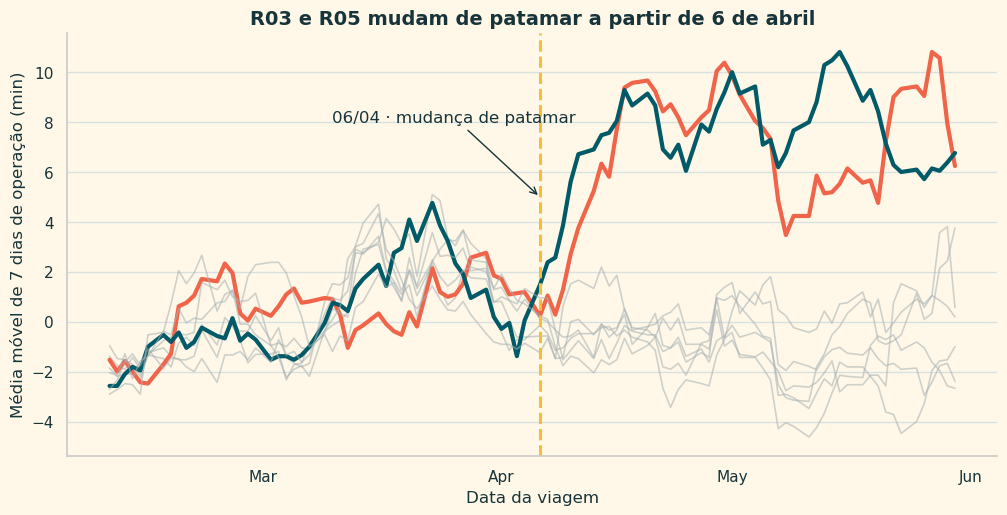

In [13]:
# Calcula primeiro uma média por dia e rota.
daily_average = data.groupby(
    ["data", "rota"]
)["atraso_min"].mean().unstack()

# A janela usa sete dias de operação completos.
daily = daily_average.rolling(window=7, min_periods=7).mean()
fig, ax = plt.subplots(figsize=(12, 5.5))
for route in daily.columns:
    color, width, alpha = GRAY, 1.2, 0.55
    if route == "R03": color, width, alpha = CORAL, 3.0, 1
    if route == "R05": color, width, alpha = TEAL, 3.0, 1
    ax.plot(daily.index, daily[route], color=color, lw=width, alpha=alpha)
ax.axvline(pd.Timestamp("2026-04-06"), color=YELLOW, lw=2.2, ls="--")
ax.annotate("06/04 · mudança de patamar", xy=(pd.Timestamp("2026-04-06"), 5),
            xytext=(pd.Timestamp("2026-03-10"), 8),
            arrowprops={"arrowstyle": "->", "color": INK})
ax.set(title="R03 e R05 mudam de patamar a partir de 6 de abril",
       xlabel="Data da viagem", ylabel="Média móvel de 7 dias de operação (min)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(axis="x", visible=False)
sns.despine()
plt.show()

**Evidência:** até o início de abril, as oito rotas oscilam perto de zero; depois de 06/04, R03 e R05 ficam entre 7 e 15 minutos.  
**Interpretação:** houve uma ruptura localizada, não uma piora gradual de toda a operação.  
**Hipótese:** as duas rotas passaram a enfrentar uma restrição compartilhada no corredor.  
**Limitação:** a linha marca uma mudança observada, não prova qual evento a causou.

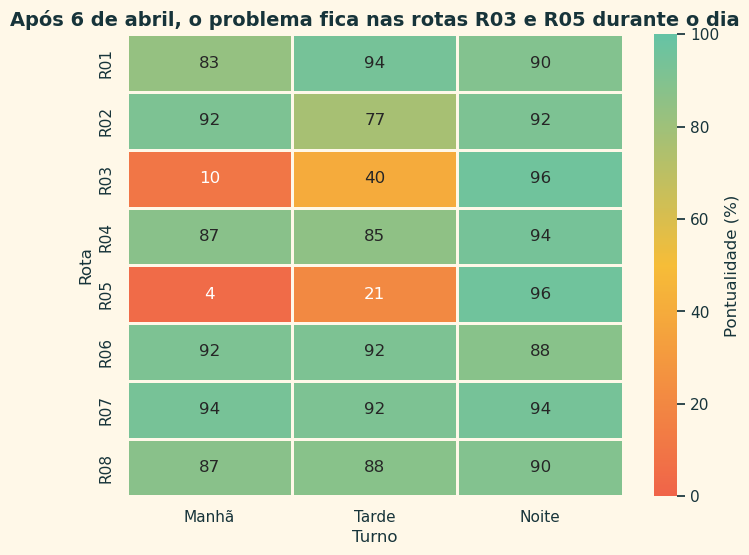

In [14]:
# Recorta o período posterior para localizar rota e turno.
after_change = data[data["data"] >= "2026-04-06"]
heatmap = (
    after_change.pivot_table(index="rota", columns="turno", values="pontual", aggfunc="mean")
    .reindex(columns=["Manhã", "Tarde", "Noite"]).mul(100).astype(float)
)
cmap = sns.blend_palette([CORAL, YELLOW, MINT], as_cmap=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap, annot=True, fmt=".0f", vmin=0, vmax=100, cmap=cmap,
            linewidths=2, linecolor=CREAM, cbar_kws={"label": "Pontualidade (%)"}, ax=ax)
ax.set(title="Após 6 de abril, o problema fica nas rotas R03 e R05 durante o dia",
       xlabel="Turno", ylabel="Rota")
plt.show()

**Evidência:** a pontualidade cai para 10% e 40% em R03, e para 4% e 21% em R05, na manhã e tarde; à noite permanece em 96%.  
**Interpretação:** turno e rota interagem. O problema não é da rota durante as 24 horas.  
**Hipótese:** uma condição diurna no corredor compartilhado é compatível com o padrão.  
**Limitação:** não temos percurso GPS, duração por trecho nem horário de vigência da obra.

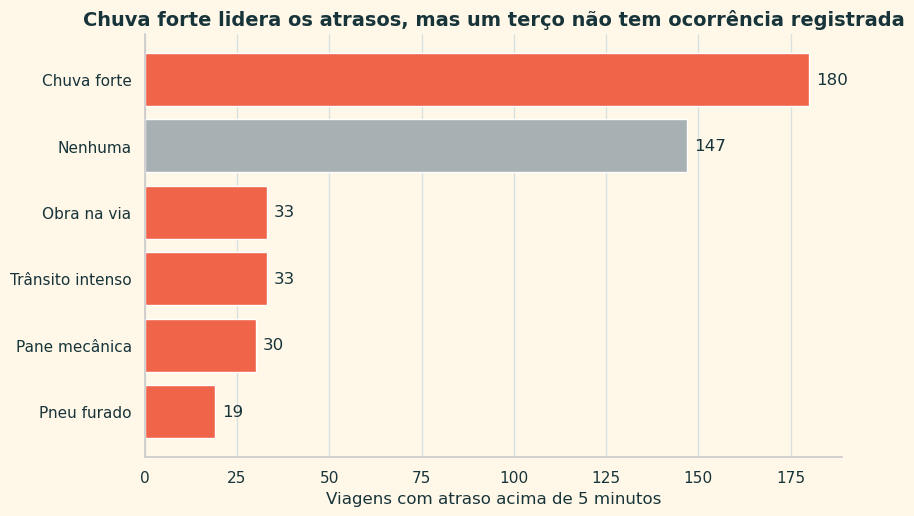

Viagens atrasadas por ocorrência e mês:


mes,2026-02,2026-03,2026-04,2026-05
ocorrencia,,,,
Chuva forte,14,97,56,13
Nenhuma,12,16,52,67
Obra na via,0,0,17,16
Pane mecânica,3,9,6,12
Pneu furado,4,5,5,5
Trânsito intenso,12,7,4,10


In [15]:
# Conta as ocorrências somente entre viagens não pontuais.
late = data[data["pontual"].eq(False)]
occurrences = late["ocorrencia"].value_counts().sort_values()
bar_colors = [GRAY if label == "Nenhuma" else CORAL for label in occurrences.index]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(occurrences.index, occurrences.values, color=bar_colors)
ax.bar_label(bars, padding=5)
ax.set(title="Chuva forte lidera os atrasos, mas um terço não tem ocorrência registrada",
       xlabel="Viagens com atraso acima de 5 minutos", ylabel="")
ax.grid(axis="y", visible=False)
sns.despine()
plt.show()

print("Viagens atrasadas por ocorrência e mês:")
display(pd.crosstab(late["ocorrencia"], late["mes"]))

**Evidência:** chuva forte aparece em 180 viagens atrasadas; 147 atrasos não têm ocorrência registrada. Pane mecânica tem mediana mais alta, mas apenas 30 registros. Chuva forte domina em março e diminui até maio, enquanto “Obra na via” surge em abril e continua em maio.

**Interpretação:** chuva é frequente e pane é severa; nenhum dos dois, isoladamente, explica a concentração temporal e geográfica. A ocorrência que cresce junto com a ruptura é obra.

**Hipótese:** ocorrências pontuais agravam o resultado, enquanto a ruptura tem componente estrutural.  
**Limitação:** o campo depende do registro do motorista e pode sofrer subnotificação.

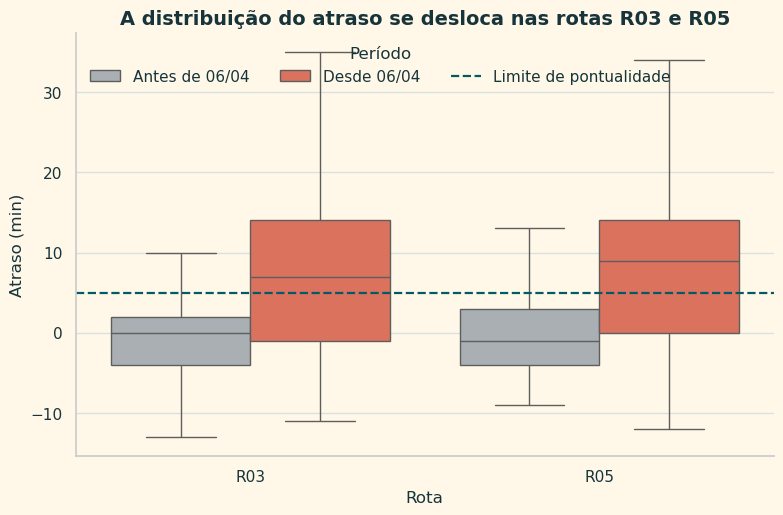

média  mediana  desvio
rota periodo_ruptura                        
R03  Antes de 06/04     0.2      0.0     7.0
     Desde 06/04        7.2      7.0    10.7
R05  Antes de 06/04     0.1     -1.0     6.8
     Desde 06/04        7.7      9.0    10.5

In [16]:
# Compara a distribuição antes e depois da ruptura.
box_data = data[data["rota"].isin(["R03", "R05"])]
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=box_data, x="rota", y="atraso_min", hue="periodo_ruptura",
            hue_order=["Antes de 06/04", "Desde 06/04"],
            palette=[GRAY, CORAL], showfliers=False, ax=ax)
ax.axhline(5, color=TEAL, ls="--", lw=1.6, label="Limite de pontualidade")
ax.set(title="A distribuição do atraso se desloca nas rotas R03 e R05",
       xlabel="Rota", ylabel="Atraso (min)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Período", frameon=False, ncol=3, loc="upper left")
sns.despine()
plt.show()

display(
    box_data.groupby(["rota", "periodo_ruptura"])["atraso_min"]
    .agg(média="mean", mediana="median", desvio="std")
    .round(1)
)

**Evidência:** a mediana das duas rotas passa de valores próximos de zero para patamares acima do limite de pontualidade.  
**Interpretação:** não é apenas um pequeno conjunto de extremos; a distribuição inteira se desloca.  
**Hipótese:** a operação cotidiana das duas rotas mudou após 06/04.  
**Média ou mediana?** Na base tratada as duas medidas apresentam a mesma mudança. A mediana continua sendo mais segura para o indicador complementar porque sofre menos influência de extremos. A média é usada na janela móvel por ser o cálculo solicitado para suavizar a tendência diária.

**Limitação:** o boxplot agrega manhã, tarde e noite; o heatmap anterior é necessário para localizar o turno.

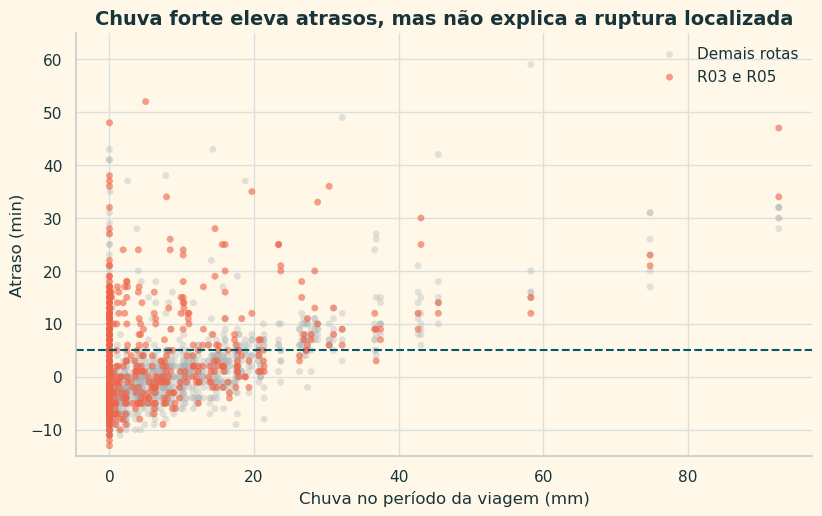

Correlação de Spearman entre chuva e atraso: 0.46
Desde 06/04, turnos diurnos, por faixa de chuva:


viagens           pontualidade           
grupo_rotas      Demais rotas R03 e R05 Demais rotas  R03 e R05
chuva_mm                                                       
Sem chuva                 299        99    95.317726  26.262626
Leve (0-10]               149        50    95.973154       16.0
Moderada (10-25]           83        28    80.722892   3.571429
Forte (>25)                30        10          0.0        0.0

In [17]:
# Mantém somente pares observados de chuva e atraso.
rain = data.dropna(subset=["chuva_mm", "atraso_min"])
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for group, color, alpha in [("Demais rotas", GRAY, 0.32), ("R03 e R05", CORAL, 0.62)]:
    subset = rain[rain["grupo_rotas"].eq(group)]
    ax.scatter(subset["chuva_mm"], subset["atraso_min"], s=25, alpha=alpha,
               color=color, label=group, edgecolors="none")
ax.axhline(5, color=TEAL, ls="--", lw=1.5)
ax.set(title="Chuva forte eleva atrasos, mas não explica a ruptura localizada",
       xlabel="Chuva no período da viagem (mm)", ylabel="Atraso (min)", ylim=(-15, 65))
ax.legend(frameon=False)
sns.despine()
plt.show()

correlation = rain[["chuva_mm", "atraso_min"]].corr(method="spearman").iloc[0, 1]
print(f"Correlação de Spearman entre chuva e atraso: {correlation:.2f}")

# Controla período e turno para comparar grupos sob a mesma chuva.
rain_band = pd.cut(
    rain["chuva_mm"],
    [-np.inf, 0, 10, 25, np.inf],
    labels=["Sem chuva", "Leve (0-10]", "Moderada (10-25]", "Forte (>25)"],
)
controlled_rain = rain[
    rain["data"].ge("2026-04-06")
    & rain["turno"].isin(["Manhã", "Tarde"])
]
punctuality_by_rain = controlled_rain.groupby(
    [rain_band[controlled_rain.index], controlled_rain["grupo_rotas"]],
    observed=True,
)["pontual"].agg(viagens="size", pontualidade="mean")
punctuality_by_rain["pontualidade"] *= 100
print("Desde 06/04, turnos diurnos, por faixa de chuva:")
display(punctuality_by_rain.round(1).unstack("grupo_rotas"))

**Evidência:** há associação moderada entre chuva e atraso (Spearman ≈ 0,46), principalmente acima de 25 mm. Desde 06/04, nos turnos diurnos e sem chuva, R03/R05 têm 26% de pontualidade contra 95% nas demais rotas. Com chuva forte os dois grupos pioram.

**Interpretação:** chuva funciona como fator agravante geral, não como explicação suficiente da ruptura. Mesmo sem chuva, a diferença entre os grupos permanece próxima de 70 pontos percentuais.

**Hipótese:** a restrição do corredor e a chuva podem se somar.  
**Limitação:** correlação não mede causalidade e chuva é medida no período, não ao longo de cada trajeto.

## Síntese numérica

Agora comparamos o grupo crítico com as demais rotas no mesmo período e nos mesmos turnos.

In [18]:
# Compara o grupo crítico com as demais rotas no mesmo recorte.
daytime_after = data[
    (data["data"] >= "2026-04-06")
    & data["turno"].isin(["Manhã", "Tarde"])
]
summary = daytime_after.groupby("grupo_rotas").agg(
    viagens=("atraso_min", "count"),
    pontualidade=("pontual", "mean"),
    mediana_atraso=("atraso_min", "median"),
    após_turno=("apos_inicio_turno", "sum"),
)
summary["pontualidade"] *= 100
display(summary.round(1))

roadwork = data[data["ocorrencia"].eq("Obra na via")]
print("Obra na via por rota:")
display(roadwork.groupby("rota").agg(
    registros=("data", "size"), início=("data", "min"), fim=("data", "max")
))

,viagens,pontualidade,mediana_atraso,após_turno
grupo_rotas,,,,
Demais rotas,573,88.481675,-2.0,14
R03 e R05,191,18.848168,12.0,53


Obra na via por rota:


,registros,início,fim
rota,,,
R03,19,2026-04-07,2026-05-28
R05,20,2026-04-08,2026-05-30


## Quadro final das hipóteses

| Hipótese | Evidência a favor | Evidência contra ou limitação | Decisão |
|---|---|---|---|
| H1 · Chuva explica a piora | Associação moderada; 180 atrasos com chuva forte | Afeta todas as rotas e não coincide com a ruptura localizada | **Inconclusiva como causa principal; mantida como agravante** |
| H2 · Restrição no corredor R03/R05 | Ruptura em 06/04, somente diurna; “Obra na via” surge em 07/04 apenas nessas rotas | Falta cronograma da obra e GPS por trecho | **Mantida como explicação mais plausível** |
| H3 · Falhas isoladas explicam a piora | Pane e pneu geram atrasos severos | Poucos casos e dispersos; distribuição inteira muda | **Rejeitada como explicação principal** |

O fato de R07 e R08, também operadas pela Viação Beta, permanecerem estáveis enfraquece uma explicação baseada apenas na empresa.

# Preparação da narrativa

## Mensagem central · 28 palavras

> **A pontualidade de R03 e R05 caiu nos turnos diurnos desde 6 de abril; obras no corredor são a explicação mais plausível, a confirmar com GPS e cronogramas.**

## Storyboard em três atos

| Ato | O que contar | O que mostrar |
|---|---|---|
| 1 · Problema | A pontualidade geral esconde uma ruptura localizada | Série temporal com marca em 06/04 |
| 2 · Investigação | Chuva agrava, mas não separa as rotas; limpeza remove distorções | Dispersão, heatmap e antes × depois |
| 3 · Resolução | Corredor compartilhado é a hipótese mais plausível; falta confirmação operacional | Gráfico explicativo e três ações |

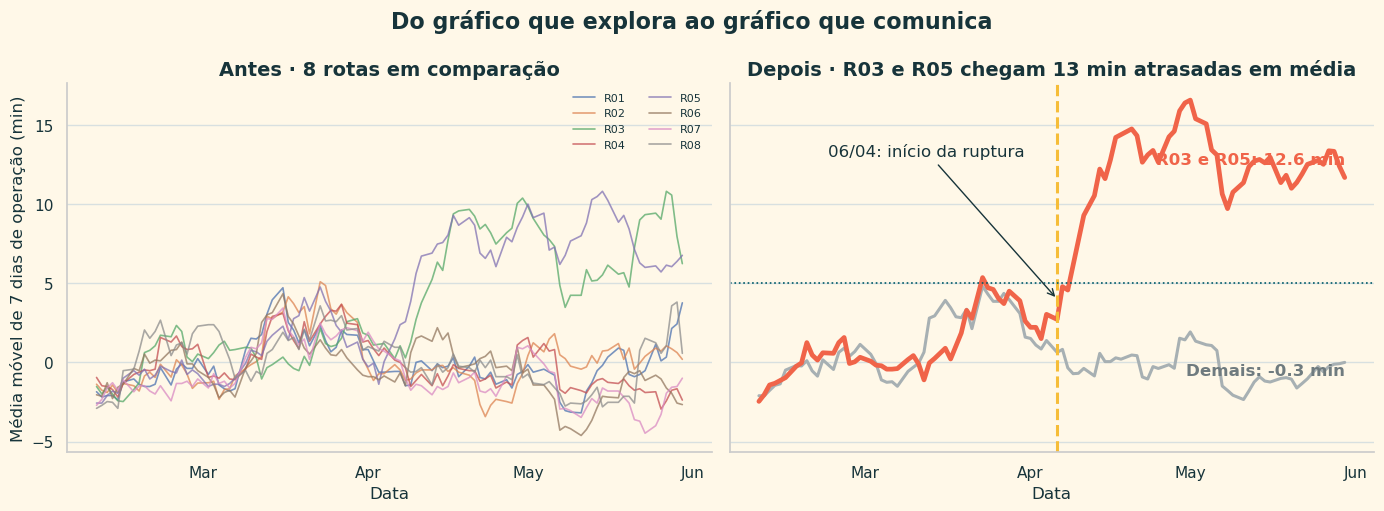

In [19]:
# Mantém manhã e tarde, onde a ruptura foi observada.
daytime = data[data["turno"].isin(["Manhã", "Tarde"])]
grouped_daily = daytime.groupby(
    ["data", "grupo_rotas"]
)["atraso_min"].mean().unstack()
grouped = grouped_daily.rolling(window=7, min_periods=7).mean()

after_group_mean = (
    daytime[daytime["data"].ge("2026-04-06")]
    .groupby("grupo_rotas")["atraso_min"]
    .mean()
)

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for route in daily.columns:
    left.plot(daily.index, daily[route], lw=1.2, alpha=0.75, label=route)
left.set(title="Antes · 8 rotas em comparação", xlabel="Data",
         ylabel="Média móvel de 7 dias de operação (min)")
left.legend(ncol=2, frameon=False, fontsize=8)

right.plot(grouped.index, grouped["Demais rotas"], color=GRAY, lw=2.2)
right.plot(grouped.index, grouped["R03 e R05"], color=CORAL, lw=3.4)
right.axvline(pd.Timestamp("2026-04-06"), color=YELLOW, lw=2.2, ls="--")
right.axhline(5, color=TEAL, lw=1.2, ls=":")
right.annotate("06/04: início da ruptura", xy=(pd.Timestamp("2026-04-06"), 4),
               xytext=(pd.Timestamp("2026-02-22"), 13),
               arrowprops={"arrowstyle": "->", "color": INK})
right.text(
    grouped.index[-1], grouped["R03 e R05"].iloc[-1] + 0.8,
    f"R03 e R05: {after_group_mean['R03 e R05']:.1f} min",
    color=CORAL, fontweight="bold", ha="right",
)
right.text(
    grouped.index[-1], grouped["Demais rotas"].iloc[-1] - 0.8,
    f"Demais: {after_group_mean['Demais rotas']:.1f} min",
    color="#6F7B7F", fontweight="bold", ha="right",
)
right.set(
    title="Depois · R03 e R05 chegam 13 min atrasadas em média",
    xlabel="Data",
)

for axis in (left, right):
    axis.xaxis.set_major_locator(mdates.MonthLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    axis.grid(axis="x", visible=False)
    sns.despine(ax=axis)
plt.suptitle("Do gráfico que explora ao gráfico que comunica", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Resposta à Pergunta Central

> **Por que os atrasos do transporte fretado aumentaram, onde se concentram e quais evidências sustentam a explicação mais plausível?**

| Parte da pergunta | Resposta sustentada pelos dados |
|---|---|
| Por que aumentaram? | A explicação mais plausível é uma restrição diurna no corredor compartilhado por R03 e R05, compatível com obra na via. A chuva agrava os atrasos, mas não explica a concentração. |
| Onde se concentram? | Em R03 e R05, nos turnos da manhã e tarde, a partir de 6 de abril de 2026. O turno noturno e as demais rotas permanecem próximos do padrão anterior. |
| Quais evidências sustentam a explicação? | A média móvel muda de patamar em 06/04; a pontualidade diurna de R03/R05 cai para 18,8% contra 88,5% nas demais; a mediana chega a 12 minutos; o problema permanece sem chuva; e os registros de obra aparecem somente nas duas rotas. |

**Resposta integrada:** os atrasos aumentaram de forma localizada, não em toda a operação. O conjunto das evidências favorece a hipótese de uma restrição diurna no corredor de R03 e R05.

**Limitação central:** a base mostra associação temporal e operacional, mas não prova causalidade nem identifica o trecho exato. A confirmação exige GPS e cronogramas de obra.

### Próximas ações

- cruzar o período com cronograma e localização das obras públicas;
- coletar GPS e tempo por trecho de R03/R05 por duas semanas;
- testar desvio de rota ou antecipação de 15 minutos nos turnos diurnos, acompanhando pontualidade e tempo total.

### Pontos de aprendizado

- a média geral pode esconder um problema localizado;
- limpeza reproduzível muda números, mas uma conclusão robusta deve sobreviver a ela;
- mediana e distribuição são essenciais quando há extremos;
- associação visual não equivale a causalidade;
- um gráfico explicativo exige seleção, contraste e anotação.

In [20]:
# Exporta somente as colunas necessárias para reproduzir a análise.
output_columns = [
    "data", "turno", "rota", "zona_origem", "empresa",
    "horario_previsto", "horario_chegada", "atraso_min",
    "passageiros", "chuva_mm", "ocorrencia", "pontual",
    "apos_inicio_turno",
]
treated_path = (
    Path("dataset/dados_tratados_transporte_fretado.csv")
    if Path("dataset").is_dir()
    else Path("dados_tratados_transporte_fretado.csv")
)
data[output_columns].to_csv(treated_path, index=False, date_format="%Y-%m-%d")
print(f"Base tratada salva em: {treated_path.resolve()}")

Base tratada salva em: /home/cronos-1226/Documentos/SiaLabs/cursos-denken/fundamentos-de-ia/entrega-final/TransitTrace/dataset/dados_tratados_transporte_fretado.csv
